In [388]:
import numpy as np
import math
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

%matplotlib inline

In [389]:
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)} is available.")
else:
    print("No GPU available. Training will run on CPU.")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

No GPU available. Training will run on CPU.
Using device: cpu


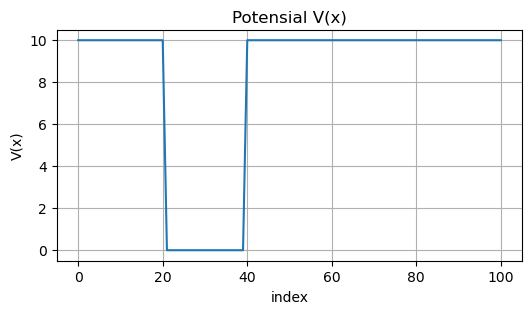

In [390]:
# Sesuaikan path ini ke lokasi file Anda
DATA_PATH = '/Users/jarulrozki/Downloads/data berhasil/kotak15_bener_lebar.npz'


data = np.load(DATA_PATH)
potensial_dataset = data['potensial']

# Cek konsistensi: pastikan semua sample punya V(x) yang sama
assert np.allclose(potensial_dataset, potensial_dataset[0]), \
    "V(x) bervariasi antar sample -> definisi V(x) di bawah perlu disesuaikan per-sample"

V_REF = potensial_dataset[0]      # (101,) -- definisi tunggal yang dipakai di semua sel
N_POINTS = len(V_REF)
DX = 0.1                          # spasi grid, dipakai konsisten di normalisasi & FDTD

plt.figure(figsize=(6,3))
plt.plot(V_REF)
plt.title('Potensial V(x)')
plt.xlabel('index'); plt.ylabel('V(x)')
plt.grid(True)
plt.show()

In [391]:
psi_awal  = data['psi_awal'].astype(np.float32)
psi_akhir = data['psi_akhir'].astype(np.float32)

X_psi_raw = psi_awal
y_raw     = psi_akhir

# Skala GLOBAL tunggal (bukan per-sample) -> psi_awal & psi_akhir tetap
# konsisten secara fisika relatif satu sama lain.
GLOBAL_SCALE = max(np.abs(X_psi_raw).max(), np.abs(y_raw).max())

X_psi = X_psi_raw / GLOBAL_SCALE
y     = y_raw / GLOBAL_SCALE

# ==========================================================
# INPUT KEDUA: Potensial V(x)
# V_REF sama untuk semua sample (sesuai definisi di sel sebelumnya),
# jadi kita ulang (tile) supaya bentuknya sejajar dengan X_psi.
# ==========================================================
V_SCALE = np.abs(V_REF).max()
V_SCALE = V_SCALE if V_SCALE > 0 else 1.0

X_V = np.tile(V_REF / V_SCALE, (X_psi.shape[0], 1)).astype(np.float32)

print("Shape X_psi:", X_psi.shape)
print("Shape X_V  :", X_V.max)
print("Shape y    :", y.shape)


Shape X_psi: (5000, 101)
Shape X_V  : <built-in method max of numpy.ndarray object at 0x32517d1d0>
Shape y    : (5000, 101)


In [392]:
(X_psi_train, X_psi_test,
 X_V_train,   X_V_test,
 y_train,     y_test) = train_test_split(
    X_psi, X_V, y, test_size=0.2, random_state=42
)

X_psi_train_tensor = torch.tensor(X_psi_train, dtype=torch.float32).to(device)
X_V_train_tensor   = torch.tensor(X_V_train,   dtype=torch.float32).to(device)
y_train_tensor      = torch.tensor(y_train,     dtype=torch.float32).to(device)

X_psi_test_tensor  = torch.tensor(X_psi_test, dtype=torch.float32).to(device)
X_V_test_tensor    = torch.tensor(X_V_test,   dtype=torch.float32).to(device)
y_test_tensor       = torch.tensor(y_test,     dtype=torch.float32).to(device)

train_dataset = TensorDataset(X_psi_train_tensor, X_V_train_tensor, y_train_tensor)
test_dataset  = TensorDataset(X_psi_test_tensor,  X_V_test_tensor,  y_test_tensor)
train_loader  = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader   = DataLoader(test_dataset,  batch_size=64, shuffle=False)

print("X_psi_train:", X_psi_train_tensor.shape)
print("X_V_train  :", X_V_train_tensor.shape)
print("X_psi_test :", X_psi_test_tensor.shape)
print("X_V_test   :", X_V_test_tensor.shape)


X_psi_train: torch.Size([4000, 101])
X_V_train  : torch.Size([4000, 101])
X_psi_test : torch.Size([1000, 101])
X_V_test   : torch.Size([1000, 101])


In [393]:
import torch
import torch.nn as nn

class NN(nn.Module):

    def __init__(self, dim=101, hidden=64, n_layers=2):
        super().__init__()

        # Cabang untuk fungsi gelombang psi(x)
        self.psi_branch = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.GELU(),
        )

        # Cabang untuk potensial V(x)
        self.v_branch = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.GELU(),
        )

        # Hidden layer setelah kedua cabang digabung
        layers = []
        layers.append(nn.Linear(hidden * 2, hidden))
        layers.append(nn.GELU())

        for _ in range(n_layers - 1):
            layers.append(nn.Linear(hidden, hidden))
            layers.append(nn.GELU())

        # Output layer -> psi_akhir(x)
        layers.append(nn.Linear(hidden, dim))

        self.gabungan = nn.Sequential(*layers)

    def forward(self, psi, V):
        psi_feat = self.psi_branch(psi)
        v_feat   = self.v_branch(V)
        fitur    = torch.cat([psi_feat, v_feat], dim=1)
        return self.gabungan(fitur)


In [394]:
import copy
import torch
import torch.nn as nn

def run(
    dim=101,
    hidden=64,
    n_layers=4,
    lr=1e-3,
    weight_decay=1e-5,
    step_size=20,
    gamma=0.5,
    n_epochs=100,
):

    # Model
    model = NN(
        dim=dim,
        hidden=hidden,
        n_layers=n_layers,
    ).to(device)

    # Optimizer
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )

    # Scheduler
    scheduler = torch.optim.lr_scheduler.StepLR(
        optimizer,
        step_size=step_size,
        gamma=gamma,
    )

    # Loss function
    criterion = nn.MSELoss()

    train_losses = []
    test_losses = []

    best_loss = float("inf")
    best_model = copy.deepcopy(model.state_dict())

    for epoch in range(n_epochs):

        # ================= TRAIN =================
        model.train()

        total_train_loss = 0

        for X_psi_batch, X_V_batch, y_train_batch in train_loader:

            X_psi_batch   = X_psi_batch.to(device)
            X_V_batch     = X_V_batch.to(device)
            y_train_batch = y_train_batch.to(device)

            optimizer.zero_grad()

            y_pred = model(X_psi_batch, X_V_batch)

            loss = criterion(
                y_pred,
                y_train_batch
            )

            loss.backward()

            optimizer.step()

            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # ================= VALIDATION =================
        model.eval()

        total_test_loss = 0

        with torch.no_grad():

            for X_psi_test_batch, X_V_test_batch, y_test_batch in test_loader:

                X_psi_test_batch = X_psi_test_batch.to(device)
                X_V_test_batch   = X_V_test_batch.to(device)
                y_test_batch     = y_test_batch.to(device)

                y_pred = model(X_psi_test_batch, X_V_test_batch)

                loss = criterion(
                    y_pred,
                    y_test_batch
                )

                total_test_loss += loss.item()

        avg_test_loss = total_test_loss / len(test_loader)
        test_losses.append(avg_test_loss)

        # Save best model
        if avg_test_loss < best_loss:
            best_loss = avg_test_loss
            best_model = copy.deepcopy(
                model.state_dict()
            )


        
        scheduler.step()

    # Load best model
    model.load_state_dict(best_model)

    return (
        best_loss,
        model,
        train_losses,
        test_losses,
    )


In [409]:
least_val_loss = float("inf")
least_loss_model = None
best_train_losses = None
best_test_losses = None
best_hyperparams = None

# Hyperparameter ANN
hidden_list = [16, 32]
n_layers_list = [2, 3, 4]

total = (
    len(hidden_list)
    * len(n_layers_list)
)

print(f"→ Total kombinasi: {total} hyperparameter\n")

counter = 0

for hidden in hidden_list:
    for n_layers in n_layers_list:

            counter += 1

            print(
                f"[{counter}/{total}] "
                f"hidden={hidden}, "
                f"n_layers={n_layers}, "
            )

            val_loss, model, train_losses, test_losses = run(
                dim=101,
                hidden=hidden,
                n_layers=n_layers,
                gamma=0.5,
                n_epochs=100,
            )

            print(f"Validation Loss = {val_loss:.10f}")

            # Simpan model terbaik
            if val_loss < least_val_loss:

                least_val_loss = val_loss
                least_loss_model = model
                best_train_losses = train_losses
                best_test_losses = test_losses

                best_hyperparams = {
                    "dim": 101,
                    "hidden": hidden,
                    "n_layers": n_layers,
                    "gamma": 0.5,
                }

                print("\n===== NEW BEST MODEL =====")
                print(best_hyperparams)
                print(
                    f"Best Validation Loss = "
                    f"{least_val_loss:.10f}\n"
                )

print("\n========== GRID SEARCH FINISHED ==========")
print("Best Hyperparameters:")
print(best_hyperparams)
print(
    f"Best Validation Loss = "
    f"{least_val_loss:.10f}"
)

→ Total kombinasi: 6 hyperparameter

[1/6] hidden=16, n_layers=2, 
Validation Loss = 0.0000292101

===== NEW BEST MODEL =====
{'dim': 101, 'hidden': 16, 'n_layers': 2, 'gamma': 0.5}
Best Validation Loss = 0.0000292101

[2/6] hidden=16, n_layers=3, 
Validation Loss = 0.0000293141
[3/6] hidden=16, n_layers=4, 
Validation Loss = 0.0000293140
[4/6] hidden=32, n_layers=2, 
Validation Loss = 0.0000292861
[5/6] hidden=32, n_layers=3, 
Validation Loss = 0.0000293096
[6/6] hidden=32, n_layers=4, 
Validation Loss = 0.0000293193

========== GRID SEARCH FINISHED ==========
Best Hyperparameters:
{'dim': 101, 'hidden': 16, 'n_layers': 2, 'gamma': 0.5}
Best Validation Loss = 0.0000292101


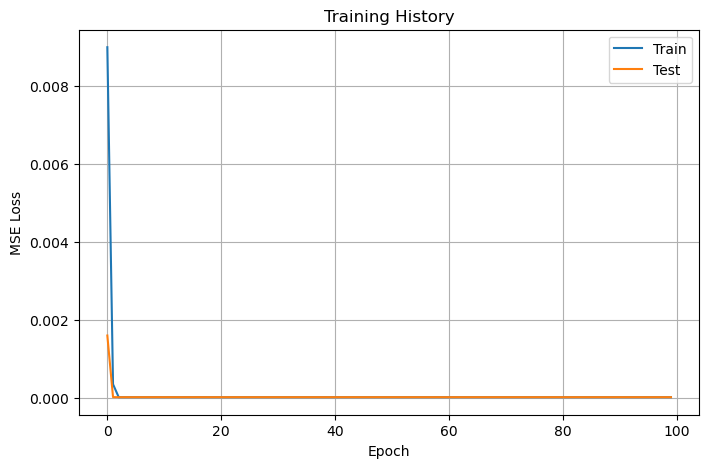

In [410]:
plt.figure(figsize=(8,5))
plt.plot(best_train_losses, label='Train')
plt.plot(best_test_losses, label='Test')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training History')
plt.legend()

plt.grid(True)
plt.show()

In [412]:
import time

X_psi_test_list, X_V_test_list, y_true_list, y_pred_list = [], [], [], []
start_time = time.perf_counter()
with torch.no_grad():
    for X_psi_batch, X_V_batch, y_batch in test_loader:
        y_pred = model(X_psi_batch, X_V_batch)
        X_psi_test_list.append(X_psi_batch.cpu())
        X_V_test_list.append(X_V_batch.cpu())
        y_true_list.append(y_batch.cpu())
        y_pred_list.append(y_pred.cpu())

end_time = time.perf_counter()
elapsed_time = end_time - start_time

X_psi_test_all = torch.cat(X_psi_test_list)
X_V_test_all   = torch.cat(X_V_test_list)
y_true_all     = torch.cat(y_true_list)
y_pred_all     = torch.cat(y_pred_list)


y_pred_denorm = y_pred_all * GLOBAL_SCALE
y_true_denorm = y_true_all * GLOBAL_SCALE

print("X_psi_test_all:", X_psi_test_all.shape)
print("X_V_test_all  :", X_V_test_all.shape)
print("y_true_denorm :", y_true_denorm.shape)
print("y_pred_denorm :", y_pred_denorm.shape)

n_samples = y_true_all.shape[0]
print(f"\nWaktu inferensi total : {elapsed_time:.4f} detik")

X_psi_test_all: torch.Size([1000, 101])
X_V_test_all  : torch.Size([1000, 101])
y_true_denorm : torch.Size([1000, 101])
y_pred_denorm : torch.Size([1000, 101])

Waktu inferensi total : 0.3377 detik


In [413]:
def normalisasi(X, dx=DX):
    X_np = X.detach().cpu().numpy().copy()
    for n in range(X_np.shape[0]):
        psi = X_np[n, :]
        sum_psi = np.sum(psi ** 2)          # seluruh titik, bukan psi[1:] (bug #7)
        if sum_psi > 0:
            A = 1.0 / np.sqrt(sum_psi * dx)
            X_np[n, :] = psi * A
    return torch.tensor(X_np, dtype=torch.float32)


def koma_formatter(x, pos):
    return f"{x:.2f}"

In [399]:
def prediksi(X, V, model, dx=0.1, tol=1e-7, max_iter=10000, simpan_dir='hasil'):
    import os
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.ticker import FuncFormatter
    import torch

    os.makedirs(simpan_dir, exist_ok=True)

    # Device mengikuti model
    device = next(model.parameters()).device
    X_normalisasi = normalisasi(X, dx).to(device)

    if torch.is_tensor(V):
        V_input = V.clone().detach().to(device=device, dtype=torch.float32)
    else:
        V_input = torch.tensor(V, dtype=torch.float32).to(device)

    if V_input.dim() == 1:
        V_input = V_input.unsqueeze(0).repeat(X_normalisasi.shape[0], 1)

    current_input = X_normalisasi.clone().detach()
    history = []

    for iterasi in range(max_iter):

        # ==========================
        # Prediksi model (dua input: psi & V)
        # ==========================
        with torch.no_grad():
            result = model(current_input, V_input)


        # ==========================
        # Normalisasi hasil prediksi
        # ==========================
        result = normalisasi(result, dx).to(device)



        # ==========================
        # Hitung perubahan
        # ==========================
        diff = torch.mean(torch.abs(result - current_input)).item()
        history.append(diff)

        print(f"Iterasi {iterasi+1}, perubahan = {diff:.6e}")

        # ==========================
        # Plot iterasi pertama & saat konvergen
        # ==========================
        if iterasi == 0 or diff < tol:

            x_plot = np.arange(result.shape[1])

            input_cpu = current_input[0, :].detach().cpu().numpy()
            result_cpu = result[0, :].detach().cpu().numpy()

            # Gunakan potensial asli (V_REF) untuk plot, bukan nilai hardcode
            v = V_REF *5

            fig, ax1 = plt.subplots(figsize=(6,4))

            ax1.plot(x_plot, input_cpu,
                     'o', color='red',
                     label=r'$\psi(x)$ Input')

            ax1.plot(x_plot, result_cpu,
                     '-', color='blue',
                     linewidth=2,
                     label=r'$\psi(x)$ Output')

            ax1.set_xlabel('x')
            ax1.set_ylabel(r'$\psi(x)$')
            ax1.grid(True)

            try:
                ax1.yaxis.set_major_formatter(FuncFormatter(koma_formatter))
            except:
                pass

            ax2 = ax1.twinx()
            ax2.plot(x_plot,
                     v,
                     '--',
                     color='green',
                     label='Potensial')

            ax2.set_ylabel(r'$V(x)$')

            lines1, labels1 = ax1.get_legend_handles_labels()
            lines2, labels2 = ax2.get_legend_handles_labels()

            ax1.legend(lines1 + lines2,
                       labels1 + labels2,
                       loc='upper center',
                       bbox_to_anchor=(0.5, -0.15),
                       ncol=3,
                       frameon=False)

            plt.tight_layout()
            plt.savefig(
                os.path.join(
                    simpan_dir,
                    f"iterasi_{iterasi+1}.png"
                ),
                dpi=300
            )
            plt.show()
            plt.close()

        # ==========================
        # Konvergen
        # ==========================
        if diff < tol:
            print(
                f"Konvergensi tercapai pada iterasi {iterasi+1} "
                f"dengan perubahan = {diff:.2e}"
            )
            break

        # ==========================
        # Output menjadi input berikutnya
        # ==========================
        current_input = result.detach().clone().to(device)

    return current_input.cpu(), result.cpu(), history


Iterasi 1, perubahan = 9.850206e-09


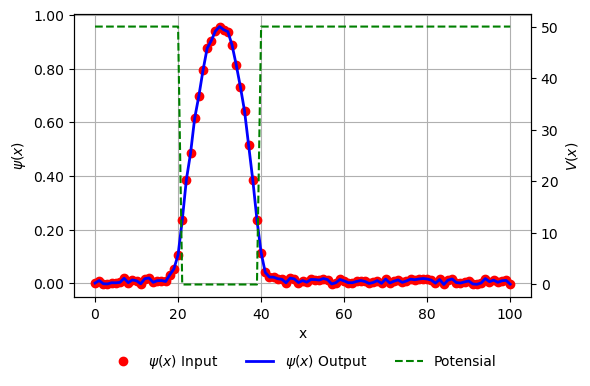

Konvergensi tercapai pada iterasi 1 dengan perubahan = 9.85e-09


In [400]:
final_input, result, history = prediksi(
    y_pred_denorm, X_V_test_all, model, dx=DX, tol=1e-7, max_iter=1000)


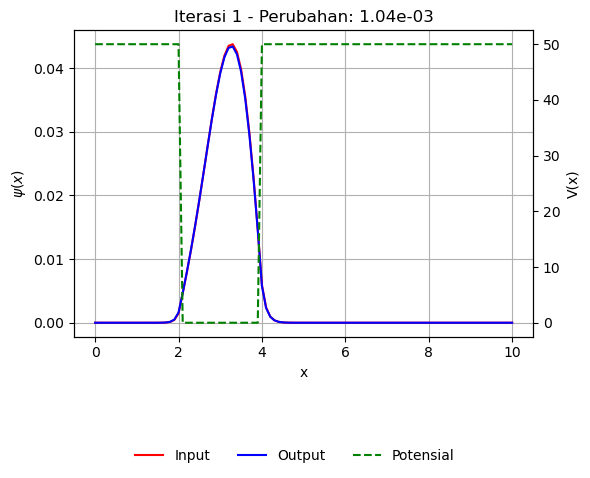

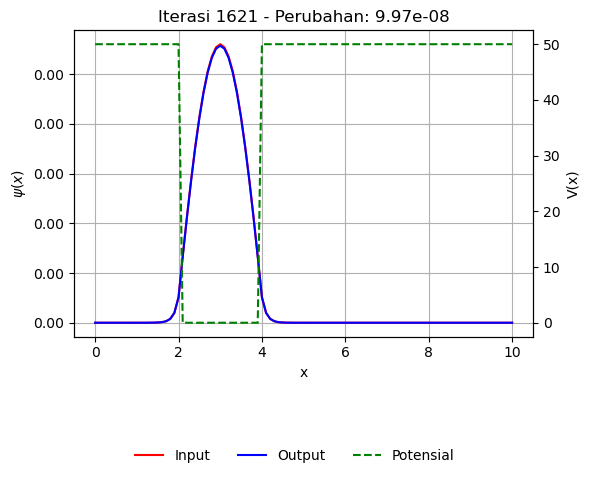

Konvergensi tercapai pada iterasi ke-1621, perubahan: 9.97e-08
Waktu komputasi FDTD    : 1.3039 detik
Shape psi_konvergen: (101,)


In [416]:
import time

def fdtd_iterasi_awal_dari_model(y_true_all, dx=0.1, L=10, dt=0.005, Nt=10000, tol=1e-7):
    Nx  = int(L / dx)
    x   = np.linspace(0, L, Nx + 1)
    dx2 = dx**2

    v = np.zeros(Nx + 1)
    for i in range(Nx + 1):
        v[i] = 50.0 if (i <= 20 or i >= 40) else 0.0

    psi     = y_true_all[0, :].detach().cpu().numpy().copy()
    history = []

    a = (1 - 0.5 * dt * v) / (1 + 0.5 * dt * v)
    b = dt / (2 * dx2 * (1 + 0.5 * dt * v))

    # --- mulai timer ---
    start_time = time.perf_counter()

    for iterasi in range(1, Nt + 1):
        psi_new       = np.zeros(Nx + 1)
        psi_new[1:-1] = (a[1:-1] * psi[1:-1]
                         + b[1:-1] * (psi[2:] - 2 * psi[1:-1] + psi[:-2]))
        psi_new[0] = psi_new[-1] = 0.0
        perubahan  = np.linalg.norm(psi_new - psi)
        history.append(perubahan)

        if iterasi == 1 or perubahan < tol:
            fig, ax1 = plt.subplots(figsize=(6, 4))
            ax1.plot(x, psi,     label='Input',  color='red')
            ax1.plot(x, psi_new, label='Output', color='blue')
            ax1.set_xlabel('x')
            ax1.set_ylabel(r'$\psi(x)$')
            ax1.tick_params(axis='y')
            ax1.grid(True)
            ax1.yaxis.set_major_formatter(FuncFormatter(koma_formatter))

            ax2 = ax1.twinx()
            ax2.plot(x, v, '--', label='Potensial', color='green')
            ax2.set_ylabel('V(x)')
            ax2.tick_params(axis='y')

            lines1, labels1 = ax1.get_legend_handles_labels()
            lines2, labels2 = ax2.get_legend_handles_labels()
            fig.legend(lines1 + lines2, labels1 + labels2,
                       loc='lower center', ncol=3,
                       bbox_to_anchor=(0.5, -0.2), frameon=False)
            plt.title(f'Iterasi {iterasi} - Perubahan: {perubahan:.2e}')
            plt.tight_layout()
            plt.savefig(f"iterasi_{iterasi}.png", dpi=800)
            plt.show()
            plt.close()

        if perubahan < tol:
            # --- selesai timer (konvergen) ---
            end_time = time.perf_counter()
            elapsed_time = end_time - start_time
            print(f"Konvergensi tercapai pada iterasi ke-{iterasi}, perubahan: {perubahan:.2e}")
            print(f"Waktu komputasi FDTD    : {elapsed_time:.4f} detik")
            np.savez('psi_konvergen_fdtd.npz', x=x, psi=psi_new, v=v)
            break

        psi = psi_new.copy()
    else:
        # --- selesai timer (Nt tercapai tanpa konvergen) ---
        end_time = time.perf_counter()
        elapsed_time = end_time - start_time
        print(f"Iterasi maksimum ({Nt}) tercapai tanpa konvergensi. Perubahan terakhir: {history[-1]:.2e}")
        print(f"Waktu komputasi FDTD    : {elapsed_time:.4f} detik")

    return psi, history

psi_konvergen, riwayat_perubahan = fdtd_iterasi_awal_dari_model(y_true_all)
print("Shape psi_konvergen:", psi_konvergen.shape)

Error relatif maksimum (per titik): 19.48%


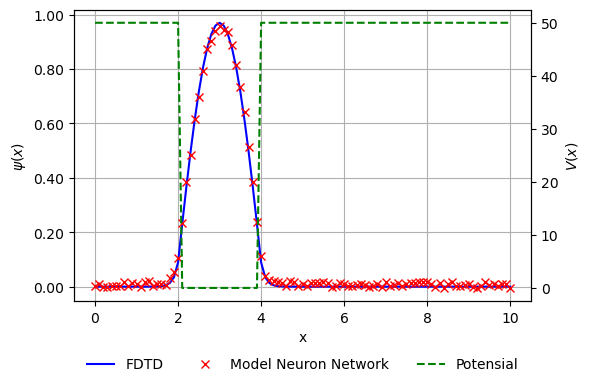

In [402]:
psi_fdtd  = psi_konvergen
psi_model = result[0,:].detach().cpu().numpy()

dx = 0.1
Nx = int(10 / dx)
x  = np.linspace(0, 10, Nx + 1)

v = np.zeros(Nx + 1)
for i in range(Nx + 1):
    v[i] = 50.0 if (i <= 20 or i >= 40) else 0.0

norm_model     = np.sqrt(np.sum(np.abs(psi_model)**2) * dx)
norm_fdtd      = np.sqrt(np.sum(np.abs(psi_fdtd)**2)  * dx)
psi_model_norm = psi_model / norm_model
psi_fdtd_norm  = psi_fdtd  / norm_fdtd

epsilon             = 0.1
error_rel_per_titik = np.abs(psi_fdtd_norm - psi_model_norm) / (np.abs(psi_fdtd_norm) + epsilon)
error_rel_max       = np.max(error_rel_per_titik)
print(f"Error relatif maksimum (per titik): {error_rel_max * 100:.2f}%")

fig, ax1 = plt.subplots(figsize=(6, 4))
ax1.plot(x, psi_fdtd_norm, label='FDTD',       color='blue')
ax1.plot(x, psi_model_norm,'x', label='Model Neuron Network', color='red')
ax1.set_xlabel('x')
ax1.set_ylabel(r'$\psi(x)$', color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.yaxis.set_major_formatter(FuncFormatter(koma_formatter))
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(x, v, label='Potensial', color='green', linestyle='--')
ax2.set_ylabel('$V(x)$', color='black')
ax2.tick_params(axis='y', labelcolor='black')

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2,
           loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=False)
plt.tight_layout()
plt.savefig("perbandingan_fdtd_VS_model1.png", dpi=800)
plt.show()

In [403]:
def hitung_energi(psi, V, dx=0.1):
    Nx    = len(psi)
    d2psi = np.zeros(Nx)
    d2psi[1:-1] = (psi[:-2] - 2 * psi[1:-1] + psi[2:]) / dx**2
    H_psi = -0.5 * d2psi + V * psi
    return np.sum(psi * H_psi) * dx

def buat_potensial(Nx):
    v = np.zeros(Nx + 1)
    for i in range(Nx + 1):
        v[i] = 50.0 if (i <= 20 or i >= 40) else 0.0
    return v

def normalisasi_np(psi, dx=0.1):
    return psi / np.sqrt(np.sum(np.abs(psi)**2) * dx)

dx = 0.1
Nx = 100
x  = np.linspace(0, Nx * dx, Nx + 1)
V  = buat_potensial(Nx)

psi_fdtd  = psi_konvergen
psi_model = result[0, :].detach().cpu().numpy()

psi_model_norm = normalisasi_np(psi_model, dx)
psi_fdtd_norm  = normalisasi_np(psi_fdtd,  dx)

E_model = hitung_energi(psi_model_norm, V, dx)
E_fdtd  = hitung_energi(psi_fdtd_norm,  V, dx)

print("=" * 50)
print("PERBANDINGAN ENERGI KEADAAN DASAR")
print("=" * 50)
print(f"Energi Model Neuron Network : {E_model:.6f}")
print(f"Energi FDTD      : {E_fdtd:.6f}")
print(f"Error Relatif    : {abs(E_model - E_fdtd) / abs(E_fdtd) * 100:.2f}%")

PERBANDINGAN ENERGI KEADAAN DASAR
Energi Model Neuron Network : 1.194359
Energi FDTD      : 1.091930
Error Relatif    : 9.38%


/var/folders/bc/krfmsqy92m1fzpb34npg9vkc0000gn/T/ipykernel_1590/3593943088.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


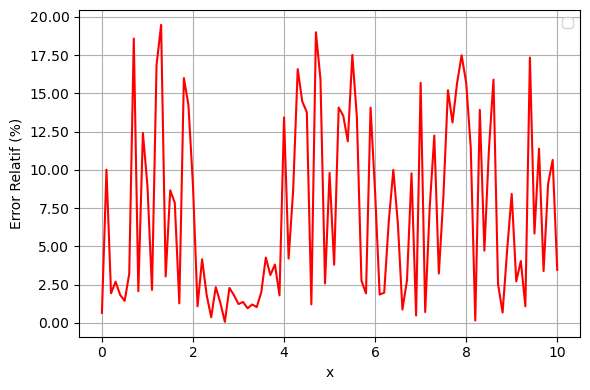

In [404]:
# ubahke bentuk persen
error_rel_percent = error_rel_per_titik * 100
# Plot
plt.figure(figsize=(6, 4))
plt.plot(x, error_rel_percent, color='red')
plt.xlabel("x")
plt.ylabel("Error Relatif (%)")
# plt.title("Error Relatif Per Titik: Model vs FDTD")
plt.grid(True)
plt.gca().yaxis.set_major_formatter(FuncFormatter(koma_formatter))
plt.legend()
plt.tight_layout()
plt.savefig("error_relatif_pertitik.png", dpi=800)
plt.show()